In [2]:
from sklearn.datasets import load_iris  # 사이킷런에서 기본 제공하는 붓꽃(Iris) 데이터셋 불러오기
import pandas as pd                      # 데이터 분석 및 전처리를 위한 판다스(Pandas) 라이브러리 불러오기
import matplotlib.pyplot as plt          # 데이터 시각화를 위한 매트플롯립(Matplotlib) 라이브러리 불러오기

iris = load_iris()                       # 붓꽃 데이터셋을 로드하여 iris 변수에 저장 (데이터, 타겟, 피처 이름 포함)
iris_df = pd.DataFrame(data=iris.data, columns=iris.feature_names) # 피처 데이터(꽃잎/꽃받침 길이·너비)를 DataFrame으로 변환
target_df = pd.DataFrame(data=iris.target, columns=['species'])    # 정답 라벨 데이터(0, 1, 2)를 'species' 컬럼명의 DataFrame으로 변환

# 숫자로 된 품종 라벨(0, 1, 2)을 실제 품종 이름(문자열)으로 바꿔주는 함수 정의
def converter(species):
    if species == 0:
        return 'setosa'      # 0이면 'setosa' 반환
    elif species == 1:
        return 'versicolor'  # 1이면 'versicolor' 반환
    else:
        return 'virginica'   # 2(기타)이면 'virginica' 반환

target_df['species'] = target_df['species'].apply(converter) # target_df의 'species' 컬럼에 converter 함수를 적용하여 숫자->문자 변환

iris_df = pd.concat([iris_df, target_df], axis=1)  # 피처 데이터(iris_df)와 품종 이름(target_df)을 열 방향(axis=1)으로 병합
iris_df.head()                                     # 병합된 데이터프레임의 상단 5개 행(Row)을 출력하여 확인

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [3]:
X = [iris_df['petal length (cm)'][a] for a in iris_df.index if iris_df['species'][a]=='virginica']
Y = [iris_df['sepal length (cm)'][a] for a in iris_df.index if iris_df['species'][a]=='virginica']

# 대괄호 두 개 [[]]를 써서 처음부터 2차원 DataFrame으로 바로 추출!
# X = iris_df.loc[iris_df['species'] == 'virginica', ['petal length (cm)']]
# Y = iris_df.loc[iris_df['species'] == 'virginica', 'sepal length (cm)']

print("petal length(꽃잎 길이)", X)
print("sepal length(꽃받침의 길이)", Y)

petal length(꽃잎 길이) [np.float64(6.0), np.float64(5.1), np.float64(5.9), np.float64(5.6), np.float64(5.8), np.float64(6.6), np.float64(4.5), np.float64(6.3), np.float64(5.8), np.float64(6.1), np.float64(5.1), np.float64(5.3), np.float64(5.5), np.float64(5.0), np.float64(5.1), np.float64(5.3), np.float64(5.5), np.float64(6.7), np.float64(6.9), np.float64(5.0), np.float64(5.7), np.float64(4.9), np.float64(6.7), np.float64(4.9), np.float64(5.7), np.float64(6.0), np.float64(4.8), np.float64(4.9), np.float64(5.6), np.float64(5.8), np.float64(6.1), np.float64(6.4), np.float64(5.6), np.float64(5.1), np.float64(5.6), np.float64(6.1), np.float64(5.6), np.float64(5.5), np.float64(4.8), np.float64(5.4), np.float64(5.6), np.float64(5.1), np.float64(5.1), np.float64(5.9), np.float64(5.7), np.float64(5.2), np.float64(5.0), np.float64(5.2), np.float64(5.4), np.float64(5.1)]
sepal length(꽃받침의 길이) [np.float64(6.3), np.float64(5.8), np.float64(7.1), np.float64(6.3), np.float64(6.5), np.float64(7.6), np.f

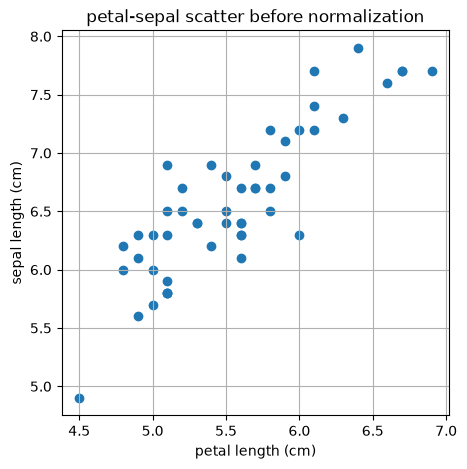

In [4]:
plt.figure(figsize=(5,5))
plt.scatter(X,Y)
plt.title('petal-sepal scatter before normalization')
plt.xlabel('petal length (cm)')
plt.ylabel('sepal length (cm)')
plt.grid()
plt.show()

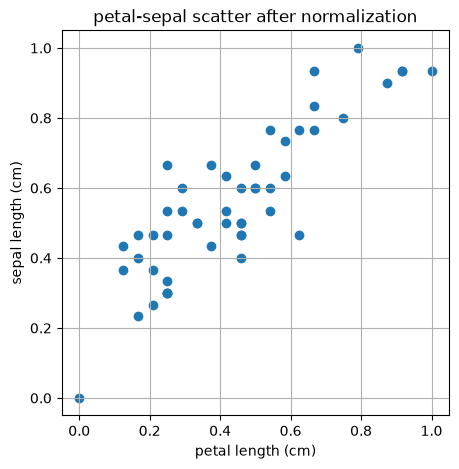

In [5]:
from sklearn.preprocessing import minmax_scale

X_scale = minmax_scale(X)
Y_scale = minmax_scale(Y)

plt.figure(figsize=(5,5))
plt.scatter(X_scale,Y_scale)
plt.title('petal-sepal scatter after normalization')
plt.xlabel('petal length (cm)')
plt.ylabel('sepal length (cm)')
plt.grid()
plt.show()

두 그래프를 비교해 보면  
(2번째 사진) 왼쪽 아래 제일 작은 값이 0,0 으로 맞춰져 있음  
X,Y를 표현하기 더 좋아짐

In [6]:
from sklearn.linear_model import LinearRegression # 사이킷런에서 선형 회귀(Linear Regression) 모델 클래스 불러오기
import numpy as np                                # 수치 계산 및 배열(Array) 처리를 위한 넘파이 라이브러리 불러오기

X = np.array(X)                                   # 입력 데이터 X를 넘파이 행렬(Array) 형태로 변환
Y = np.array(Y)                                   # 정답 데이터 Y를 넘파이 행렬(Array) 형태로 변환

# Iris Dataset을 Linear Regression으로 학습합니다.
linear = LinearRegression()                       # 선형 회귀 모델 객체 생성 (기본 알고리즘 준비)
linear.fit(X.reshape(-1, 1), Y)                   # X를 2차원 형태로 형태 변경(-1, 1)한 뒤, Y와의 관계를 학습(fit)시킴

# Linear Regression의 기울기와 절편을 확인합니다.
a, b = linear.coef_[0], linear.intercept_         # coef_ 배열의 첫 번째 값([0])에서 기울기 a를, intercept_에서 절편 b를 가져옴
print(f"기울기 : {a:.2f}, 절편 :{b:.2f}")          # 구한 기울기(a)와 절편(b)을 소수점 둘째 자리까지 변수 포맷팅(f-string)으로 출력

기울기 : 1.00, 절편 :1.06


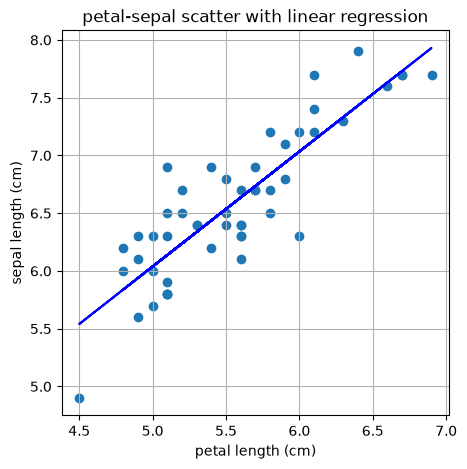

In [7]:
plt.figure(figsize=(5,5))
plt.scatter(X,Y)
plt.plot(X,linear.predict(X.reshape(-1,1)),'-b')
plt.title('petal-sepal scatter with linear regression')
plt.xlabel('petal length (cm)')
plt.ylabel('sepal length (cm)')
plt.grid()
plt.show()

기울기 : 0.00, 절편 :6.59


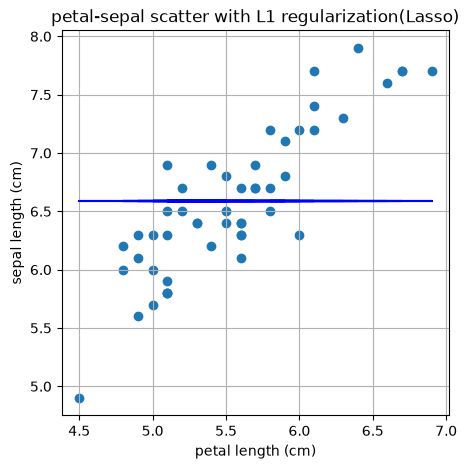

In [10]:
# Q. linear regression의 코드를 참고하여, 아래 코드를 채워주세요!

# L1 regularization은 Lasso로 import 합니다.
from sklearn.linear_model import Lasso

L1 = Lasso()
L1.fit(X.reshape(-1,1), Y)
a, b = L1.coef_[0], L1.intercept_
print(f"기울기 : {a:.2f}, 절편 :{b:.2f}")  

plt.figure(figsize=(5,5))
plt.scatter(X,Y)
plt.plot(X,L1.predict(X.reshape(-1,1)),'-b')
plt.title('petal-sepal scatter with L1 regularization(Lasso)')
plt.xlabel('petal length (cm)')
plt.ylabel('sepal length (cm)')
plt.grid()
plt.show()

기울기 : 0.93, 절편 :1.41


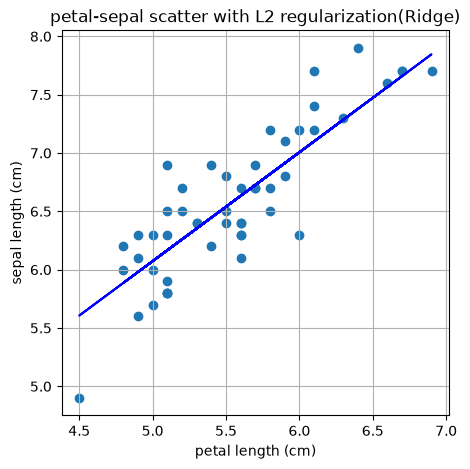

In [11]:
# Q. linear regression의 코드를 참고하여, 아래 코드를 채워주세요!

# L2 regularization은 Ridge로 import 합니다.
from sklearn.linear_model import Ridge

L2 = Ridge()
L2.fit(X.reshape(-1,1), Y)
a, b = L2.coef_[0], L2.intercept_
print(f"기울기 : {a:.2f}, 절편 :{b:.2f}")  

plt.figure(figsize=(5,5))
plt.scatter(X,Y)
plt.plot(X,L2.predict(X.reshape(-1,1)),'-b')
plt.title('petal-sepal scatter with L2 regularization(Ridge)')
plt.xlabel('petal length (cm)')
plt.ylabel('sepal length (cm)')
plt.grid()
plt.show()